In [30]:
# =========================
# Imports
# =========================
import os, json, time, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             cohen_kappa_score, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# =========================
# Device Setup
# =========================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =========================
# Config
# =========================
NUM_CLASSES  = 5
BATCH_SIZE   = 32
EPOCHS       = 3
NUM_WORKERS  = 4
RANDOM_STATE = 42

IMG_SIZE = {
    'efficientnet_b3': 300,
    'default': 224
}

INCLUDE_VGG16       = False
PREPROCESSING_TYPES = ['basic', 'enhanced']
CLASS_LABELS        = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

ENHANCED_DIR  = '/kaggle/working/enhanced_images'
MODELS_DIR    = '/kaggle/working/saved_models'
ARTIFACTS_DIR = '/kaggle/working/artifacts'


for d in (ENHANCED_DIR, MODELS_DIR, ARTIFACTS_DIR):
    os.makedirs(d, exist_ok=True)

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')

if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print(f'enhanced  -> {ENHANCED_DIR}')
print(f'models    -> {MODELS_DIR}')
print(f'artifacts -> {ARTIFACTS_DIR}')

PyTorch : 2.9.0+cu126
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
enhanced  -> /kaggle/working/enhanced_images
models    -> /kaggle/working/saved_models
artifacts -> /kaggle/working/artifacts


In [31]:
for _candidate in (
    '/kaggle/input/competitions/aptos2019-blindness-detection',
    '/kaggle/input/aptos2019-blindness-detection',
):
    _csv = os.path.join(_candidate, 'train.csv')
    if os.path.exists(_csv):
        TRAIN_CSV     = _csv
        TRAIN_IMG_DIR = os.path.join(_candidate, 'train_images')
        break
else:
    raise FileNotFoundError('APTOS 2019 dataset not found.')

_train_split_csv = os.path.join(ARTIFACTS_DIR, 'train_split.csv')
_val_split_csv   = os.path.join(ARTIFACTS_DIR, 'val_split.csv')

if os.path.exists(_train_split_csv) and os.path.exists(_val_split_csv):
  
    train_df = pd.read_csv(_train_split_csv)
    val_df   = pd.read_csv(_val_split_csv)
    df       = pd.read_csv(TRAIN_CSV)
    df['path'] = df['id_code'].apply(
        lambda x: os.path.join(TRAIN_IMG_DIR, f'{x}.png'))
    print('[CACHE] Loaded existing train/val splits from disk.')
else:
   
    df = pd.read_csv(TRAIN_CSV)
    df['path'] = df['id_code'].apply(
        lambda x: os.path.join(TRAIN_IMG_DIR, f'{x}.png'))
    train_df, val_df = train_test_split(
        df, test_size=0.2, stratify=df['diagnosis'], random_state=RANDOM_STATE)
    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)
    train_df.to_csv(_train_split_csv, index=False)
    val_df.to_csv(  _val_split_csv,   index=False)
    print('[NEW] Created and saved train/val splits.')

print(f'Dataset : {TRAIN_CSV}')
print(f'Train   : {len(train_df):,}  |  Val : {len(val_df):,}')
print()
print('Class distribution (full dataset):')
dist = df['diagnosis'].value_counts().sort_index()
for cls, cnt in dist.items():
    bar = '#' * (cnt // 100)
    print(f'  Grade {cls} ({CLASS_LABELS[cls]:14s}): {cnt:5d}  {bar}')


[CACHE] Loaded existing train/val splits from disk.
Dataset : /kaggle/input/competitions/aptos2019-blindness-detection/train.csv
Train   : 2,929  |  Val : 733

Class distribution (full dataset):
  Grade 0 (No DR         ):  1805  ##################
  Grade 1 (Mild          ):   370  ###
  Grade 2 (Moderate      ):   999  #########
  Grade 3 (Severe        ):   193  #
  Grade 4 (Proliferative ):   295  ##


In [32]:
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['diagnosis'].values,
)
CLASS_WEIGHTS = torch.tensor(class_weights_np, dtype=torch.float).to(DEVICE)

print('Per-class weights (inverse frequency):')
for i, (label, w) in enumerate(zip(CLASS_LABELS, class_weights_np)):
    print(f'  Grade {i} ({label:14s}): {w:.4f}')


Per-class weights (inverse frequency):
  Grade 0 (No DR         ): 0.4057
  Grade 1 (Mild          ): 1.9791
  Grade 2 (Moderate      ): 0.7332
  Grade 3 (Severe        ): 3.8039
  Grade 4 (Proliferative ): 2.4822


In [33]:
def _crop_black_borders(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if img.ndim == 3 else img
    mask = gray > tol
    if not mask.any():
        return img
    return img[np.ix_(mask.any(axis=1), mask.any(axis=0))]


def ben_graham(img, sigma=10, size=512):
    img = _crop_black_borders(img)
    img = cv2.resize(img, (size, size))
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), sigma), -4, 128)
    return img


def presave_enhanced(df, out_dir):
    """Pre-process images with Ben Graham filter.
    Skips images that already exist in out_dir (cache-aware).
    """
    missing = [
        row for _, row in df.iterrows()
        if not os.path.exists(os.path.join(out_dir, os.path.basename(row['path'])))
    ]
    if not missing:
        print(f'All {len(df)} enhanced images already cached in {out_dir}  [SKIP]')
        return
    print(f'Pre-processing {len(missing)} / {len(df)} images ...')
    for row in tqdm(missing, desc='Ben Graham'):
        dst = os.path.join(out_dir, os.path.basename(row['path']))
        img = cv2.imread(row['path'])
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = ben_graham(img)
        cv2.imwrite(dst, cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
                    [cv2.IMWRITE_JPEG_QUALITY, 95])
    print('Done.')


def _build_enhanced_df(split_df):
    out = split_df.copy()
    out['path'] = out['id_code'].apply(
        lambda x: os.path.join(ENHANCED_DIR, f'{x}.png'))
    return out


presave_enhanced(df, ENHANCED_DIR)

train_df_enhanced = _build_enhanced_df(train_df)
val_df_enhanced   = _build_enhanced_df(val_df)


All 3662 enhanced images already cached in /kaggle/working/enhanced_images  [SKIP]


In [34]:
class APTOSDataset(Dataset):

    def __init__(self, df, transform=None):
        self.paths     = df['path'].values
        self.labels    = df['diagnosis'].values.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        if img is None:
            raise FileNotFoundError(f'Missing: {self.paths[idx]}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

_IMAGENET_NORM = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

In [35]:
def get_transforms(arch, is_train):
    size = IMG_SIZE.get(arch, IMG_SIZE['default'])
    base = [transforms.ToPILImage(), transforms.Resize((size, size))]
    if is_train:
        aug = [
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        ]
        return transforms.Compose(base + aug + [transforms.ToTensor(), _IMAGENET_NORM])
    return transforms.Compose(base + [transforms.ToTensor(), _IMAGENET_NORM])


def _make_loader(dataset, *, batch_size, shuffle=False, sampler=None, drop_last=False):
    return DataLoader(
        dataset,
        batch_size         = batch_size,
        shuffle            = shuffle if sampler is None else False,
        sampler            = sampler,
        num_workers        = NUM_WORKERS,
        pin_memory         = True,
        persistent_workers = True,
        prefetch_factor    = 2,
        drop_last          = drop_last,
    )


def get_loaders(arch, prep):
    tr_df = train_df_enhanced if prep == 'enhanced' else train_df
    vl_df = val_df_enhanced   if prep == 'enhanced' else val_df
    train_ds = APTOSDataset(tr_df, get_transforms(arch, is_train=True))
    val_ds   = APTOSDataset(vl_df, get_transforms(arch, is_train=False))
    return (
        _make_loader(train_ds, batch_size=BATCH_SIZE,     shuffle=True, drop_last=True),
        _make_loader(val_ds,   batch_size=BATCH_SIZE * 2),
    )


def get_oversampled_loader(arch, prep):
    tr_df     = train_df_enhanced if prep == 'enhanced' else train_df
    counts    = tr_df['diagnosis'].value_counts().sort_index().values
    inv_freq  = 1.0 / torch.tensor(counts, dtype=torch.float)
    s_weights = [inv_freq[t].item() for t in tr_df['diagnosis']]
    sampler   = WeightedRandomSampler(s_weights, num_samples=len(s_weights),
                                      replacement=True)
    train_ds  = APTOSDataset(tr_df, get_transforms(arch, is_train=True))
    return _make_loader(train_ds, batch_size=BATCH_SIZE,
                        sampler=sampler, drop_last=True)


In [36]:
_MODEL_REGISTRY = {
    'resnet50'        : (models.resnet50,        models.ResNet50_Weights.DEFAULT),
    'densenet121'     : (models.densenet121,      models.DenseNet121_Weights.DEFAULT),
    'efficientnet_b3' : (models.efficientnet_b3,  models.EfficientNet_B3_Weights.DEFAULT),
    'vgg16'           : (models.vgg16,            models.VGG16_Weights.DEFAULT),
}


def get_model(arch):
    if arch not in _MODEL_REGISTRY:
        raise ValueError(f"Unknown arch '{arch}'. Options: {list(_MODEL_REGISTRY)}")
    constructor, weights = _MODEL_REGISTRY[arch]
    model = constructor(weights=weights)
    if arch == 'resnet50':
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    elif arch == 'densenet121':
        model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
    elif arch == 'efficientnet_b3':
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    elif arch == 'vgg16':
        model.classifier[6] = nn.Linear(4096, NUM_CLASSES)
    return model.to(DEVICE)


def load_checkpoint(arch, ckpt_path):
    """Rebuild model and load saved weights. Returns model in eval mode."""
    model = get_model(arch)
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    return model


In [37]:
def _train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc='  train', leave=False, dynamic_ncols=True)
    for imgs, labels in pbar:
        imgs   = imgs.to(DEVICE,   non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            loss = criterion(model(imgs), labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')
    return total_loss / len(loader)


def _val_epoch(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='  val  ', leave=False, dynamic_ncols=True):
            imgs = imgs.to(DEVICE, non_blocking=True)
            with autocast():
                out = model(imgs)
            preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            targets.extend(labels.numpy())
    return np.array(preds), np.array(targets)


def train_model(model, train_loader, val_loader, *,
                arch, checkpoint_tag,
                criterion=None, epochs=EPOCHS):
    """
    Train model, saving best checkpoint (by val accuracy) to MODELS_DIR.

    Parameters
    ----------
    arch           : Architecture key used in checkpoint filename.
    checkpoint_tag : Descriptor appended to filename, e.g. 'enhanced_classweights'.
    criterion      : Loss fn. Defaults to CrossEntropyLoss(weight=CLASS_WEIGHTS).

    Returns
    -------
    (trained model with best weights, info dict)
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler    = GradScaler()

    best_acc   = 0.0
    best_state = copy.deepcopy(model.state_dict())
    history    = []
    t0         = time.time()

    for epoch in range(1, epochs + 1):
        train_loss          = _train_epoch(model, train_loader, criterion, optimizer, scaler)
        preds, targets      = _val_epoch(model, val_loader)
        acc                 = accuracy_score(targets, preds)
        scheduler.step()
        history.append({'epoch': epoch, 'train_loss': train_loss, 'val_acc': acc})
        print(f'  Epoch {epoch}/{epochs} | loss={train_loss:.4f} | val_acc={acc:.4f}')
        if acc > best_acc:
            best_acc   = acc
            best_state = copy.deepcopy(model.state_dict())

    elapsed = time.time() - t0
    model.load_state_dict(best_state)

    ckpt_name = f'{arch}__{checkpoint_tag}.pth'
    ckpt_path = os.path.join(MODELS_DIR, ckpt_name)
    torch.save({
        'arch'       : arch,
        'tag'        : checkpoint_tag,
        'best_acc'   : best_acc,
        'state_dict' : best_state,
        'history'    : history,
    }, ckpt_path)
    print(f'  [ok] Checkpoint -> {ckpt_path}  (best_acc={best_acc:.4f})')

    return model, {'elapsed_s': elapsed, 'best_acc': best_acc,
                   'history': history, 'ckpt_path': ckpt_path, 'ckpt_name': ckpt_name}


# ─────────────────────────────────────────────────────────────────────────────
def load_or_train(arch, prep, strategy, *,
                  train_loader=None, val_loader=None,
                  criterion=None):
    """
    Load an existing checkpoint if it exists, otherwise train from scratch.

    Parameters
    ----------
    arch         : e.g. 'resnet50'
    prep         : 'basic' | 'enhanced'
    strategy     : 'class_weights' | 'oversampling'
    train_loader : required only when training (can be None for load path)
    val_loader   : always required (used for evaluation)
    criterion    : passed to train_model when training

    Returns
    -------
    (model, info_dict)
    info_dict always contains: elapsed_s, best_acc, history, ckpt_path, ckpt_name
    """
    tag       = f'{prep}_{strategy}'
    ckpt_name = f'{arch}__{tag}.pth'
    ckpt_path = os.path.join(MODELS_DIR, ckpt_name)

    if os.path.exists(ckpt_path):
        print(f'  [CACHE] Loading checkpoint: {ckpt_name}')
        model = get_model(arch)
        ckpt  = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt['state_dict'])
        model.eval()
        info = {
            'elapsed_s' : 0.0,
            'best_acc'  : ckpt.get('best_acc', float('nan')),
            'history'   : ckpt.get('history', []),
            'ckpt_path' : ckpt_path,
            'ckpt_name' : ckpt_name,
        }
        return model, info

    # checkpoint not found → train
    print(f'  [TRAIN] No checkpoint found for {ckpt_name}, training ...')
    assert train_loader is not None, 'train_loader required when no checkpoint exists'
    model = get_model(arch)
    return train_model(model, train_loader, val_loader,
                       arch=arch, checkpoint_tag=tag, criterion=criterion)


In [38]:
def evaluate_model(model, val_loader):
    """
    Full evaluation: acc, weighted-F1, quadratic-kappa, AUC-OvR.
    Also returns raw preds / targets / probs for notebook 04.
    """
    model.eval()
    preds, targets, probs = [], [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            with autocast():
                out = model(imgs)
            probs.extend(torch.softmax(out.float(), dim=1).cpu().numpy())
            preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            targets.extend(labels.numpy())

    preds, targets, probs = np.array(preds), np.array(targets), np.array(probs)

    try:
        auc = roc_auc_score(targets, probs, multi_class='ovr')
    except ValueError:
        auc = float('nan')

    return {
        'acc'     : accuracy_score(targets, preds),
        'f1'      : f1_score(targets, preds, average='weighted'),
        'kappa'   : cohen_kappa_score(targets, preds, weights='quadratic'),
        'auc'     : auc,
        'preds'   : preds,
        'targets' : targets,
        'probs'   : probs,
    }

In [39]:
MODELS_LIST = ['vgg16', 'resnet50', 'densenet121', 'efficientnet_b3']

_results_cache = os.path.join(ARTIFACTS_DIR, 'experiment_results.csv')
if os.path.exists(_results_cache):
    _cached = pd.read_csv(_results_cache)
    results = _cached.to_dict('records')
    print(f'[CACHE] Loaded {len(results)} result rows from {_results_cache}')
    print(_cached[['arch','prep','strategy','acc','f1','kappa','auc']].to_string(index=False))
else:
    results = []

# Set of (arch, prep, strategy) combos already in results
_done = {(r['arch'], r['prep'], r['strategy']) for r in results}

for prep in PREPROCESSING_TYPES:
    for arch in MODELS_LIST:
        strategy = 'class_weights'
        if (arch, prep, strategy) in _done:
            print(f'[SKIP]  {arch} | prep={prep} | strategy={strategy}  (already in results)')
            continue

        print('\n' + '=' * 60)
        print(f'  {arch}  |  prep={prep}  |  strategy={strategy}')
        print('=' * 60)

        train_loader, val_loader = get_loaders(arch, prep)

        model, info = load_or_train(
            arch, prep, strategy,
            train_loader = train_loader,
            val_loader   = val_loader,
            criterion    = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS),
        )
        m = evaluate_model(model, val_loader)

        results.append({
            'arch'     : arch,
            'prep'     : prep,
            'strategy' : strategy,
            'acc'      : round(m['acc'],   4),
            'f1'       : round(m['f1'],    4),
            'kappa'    : round(m['kappa'], 4),
            'auc'      : round(m['auc'],   4),
            'time_min' : round(info['elapsed_s'] / 60, 2),
            'ckpt_name': info['ckpt_name'],
        })
        _done.add((arch, prep, strategy))

        pd.DataFrame(results).to_csv(
            os.path.join(ARTIFACTS_DIR, 'results_temp.csv'), index=False)

        del model, train_loader, val_loader
        torch.cuda.empty_cache()

print('\n Experiment A complete.')


[CACHE] Loaded 9 result rows from /kaggle/working/artifacts/experiment_results.csv
           arch     prep      strategy    acc     f1  kappa    auc
    densenet121 enhanced class_weights 0.7749 0.7797 0.8687 0.9313
          vgg16    basic class_weights 0.7422 0.7489 0.8683 0.9295
    densenet121    basic class_weights 0.7776 0.7847 0.8639 0.9335
    densenet121 enhanced  oversampling 0.7708 0.7767 0.8637 0.9312
efficientnet_b3    basic class_weights 0.7817 0.7795 0.8566 0.9268
       resnet50    basic class_weights 0.7844 0.7886 0.8550 0.9292
       resnet50 enhanced class_weights 0.7722 0.7769 0.8512 0.9184
efficientnet_b3 enhanced class_weights 0.7653 0.7648 0.8322 0.9207
          vgg16 enhanced class_weights 0.7108 0.7116 0.8297 0.9087
[SKIP]  vgg16 | prep=basic | strategy=class_weights  (already in results)
[SKIP]  resnet50 | prep=basic | strategy=class_weights  (already in results)
[SKIP]  densenet121 | prep=basic | strategy=class_weights  (already in results)
[SKIP]  efficien

In [40]:
df_A     = pd.DataFrame([r for r in results if r['strategy'] == 'class_weights'])
best_row  = df_A.sort_values('kappa', ascending=False).iloc[0]
best_arch = best_row['arch']
best_prep = best_row['prep']

print(f'Best from Experiment A -> arch={best_arch}  prep={best_prep}  '
      f'kappa={best_row["kappa"]:.4f}')

strategy_B = 'oversampling'

if (best_arch, best_prep, strategy_B) in {(r['arch'], r['prep'], r['strategy']) for r in results}:
    print(f'[SKIP] Experiment B already done for {best_arch} | {best_prep} | {strategy_B}')
    m_B    = next(r for r in results
                  if r['arch']==best_arch and r['prep']==best_prep and r['strategy']==strategy_B)
    info_B = {'elapsed_s': m_B['time_min']*60, 'ckpt_name': m_B['ckpt_name']}
else:
    print('\n' + '=' * 60)
    print(f'  {best_arch}  |  prep={best_prep}  |  strategy={strategy_B}')
    print('=' * 60)

    _, val_loader_B   = get_loaders(best_arch, best_prep)
    train_loader_B    = get_oversampled_loader(best_arch, best_prep)

    model_B, info_B = load_or_train(
        best_arch, best_prep, strategy_B,
        train_loader = train_loader_B,
        val_loader   = val_loader_B,
        criterion    = nn.CrossEntropyLoss(),   # no weights -- sampler handles imbalance
    )
    m_B_eval = evaluate_model(model_B, val_loader_B)

    results.append({
        'arch'     : best_arch,
        'prep'     : best_prep,
        'strategy' : strategy_B,
        'acc'      : round(m_B_eval['acc'],   4),
        'f1'       : round(m_B_eval['f1'],    4),
        'kappa'    : round(m_B_eval['kappa'], 4),
        'auc'      : round(m_B_eval['auc'],   4),
        'time_min' : round(info_B['elapsed_s'] / 60, 2),
        'ckpt_name': info_B['ckpt_name'],
    })

    del model_B, train_loader_B, val_loader_B
    torch.cuda.empty_cache()

    print(f'\n[ok] Experiment B complete.')
    print(f'  oversampling -> acc={m_B_eval["acc"]:.4f}  f1={m_B_eval["f1"]:.4f}  '
          f'kappa={m_B_eval["kappa"]:.4f}  auc={m_B_eval["auc"]:.4f}')


Best from Experiment A -> arch=densenet121  prep=enhanced  kappa=0.8687
[SKIP] Experiment B already done for densenet121 | enhanced | oversampling


In [41]:
df_results = (pd.DataFrame(results)
                .sort_values('kappa', ascending=False)
                .reset_index(drop=True))

df_results.to_csv(os.path.join(ARTIFACTS_DIR, 'experiment_results.csv'), index=False)
df_results.to_csv('/kaggle/working/experiment_results.csv',               index=False)

print('All experiments -- sorted by quadratic-kappa\n')
print(df_results[['arch','prep','strategy','acc','f1','kappa','auc','time_min']]
      .to_string(index=False))

best_arch = df_results.iloc[0]['arch']
best_prep = df_results.iloc[0]['prep']
cmp = df_results[df_results['arch'] == best_arch][['strategy','acc','f1','kappa','auc']]
print(f'\nImbalance strategy comparison ({best_arch} | {best_prep}):')
print(cmp.to_string(index=False))


All experiments -- sorted by quadratic-kappa

           arch     prep      strategy    acc     f1  kappa    auc  time_min
    densenet121 enhanced class_weights 0.7749 0.7797 0.8687 0.9313      1.15
          vgg16    basic class_weights 0.7422 0.7489 0.8683 0.9295      9.75
    densenet121    basic class_weights 0.7776 0.7847 0.8639 0.9335      9.55
    densenet121 enhanced  oversampling 0.7708 0.7767 0.8637 0.9312      1.16
efficientnet_b3    basic class_weights 0.7817 0.7795 0.8566 0.9268     10.15
       resnet50    basic class_weights 0.7844 0.7886 0.8550 0.9292      9.48
       resnet50 enhanced class_weights 0.7722 0.7769 0.8512 0.9184      1.06
efficientnet_b3 enhanced class_weights 0.7653 0.7648 0.8322 0.9207      2.06
          vgg16 enhanced class_weights 0.7108 0.7116 0.8297 0.9087      1.70

Imbalance strategy comparison (densenet121 | enhanced):
     strategy    acc     f1  kappa    auc
class_weights 0.7749 0.7797 0.8687 0.9313
class_weights 0.7776 0.7847 0.8639 0.9335
 

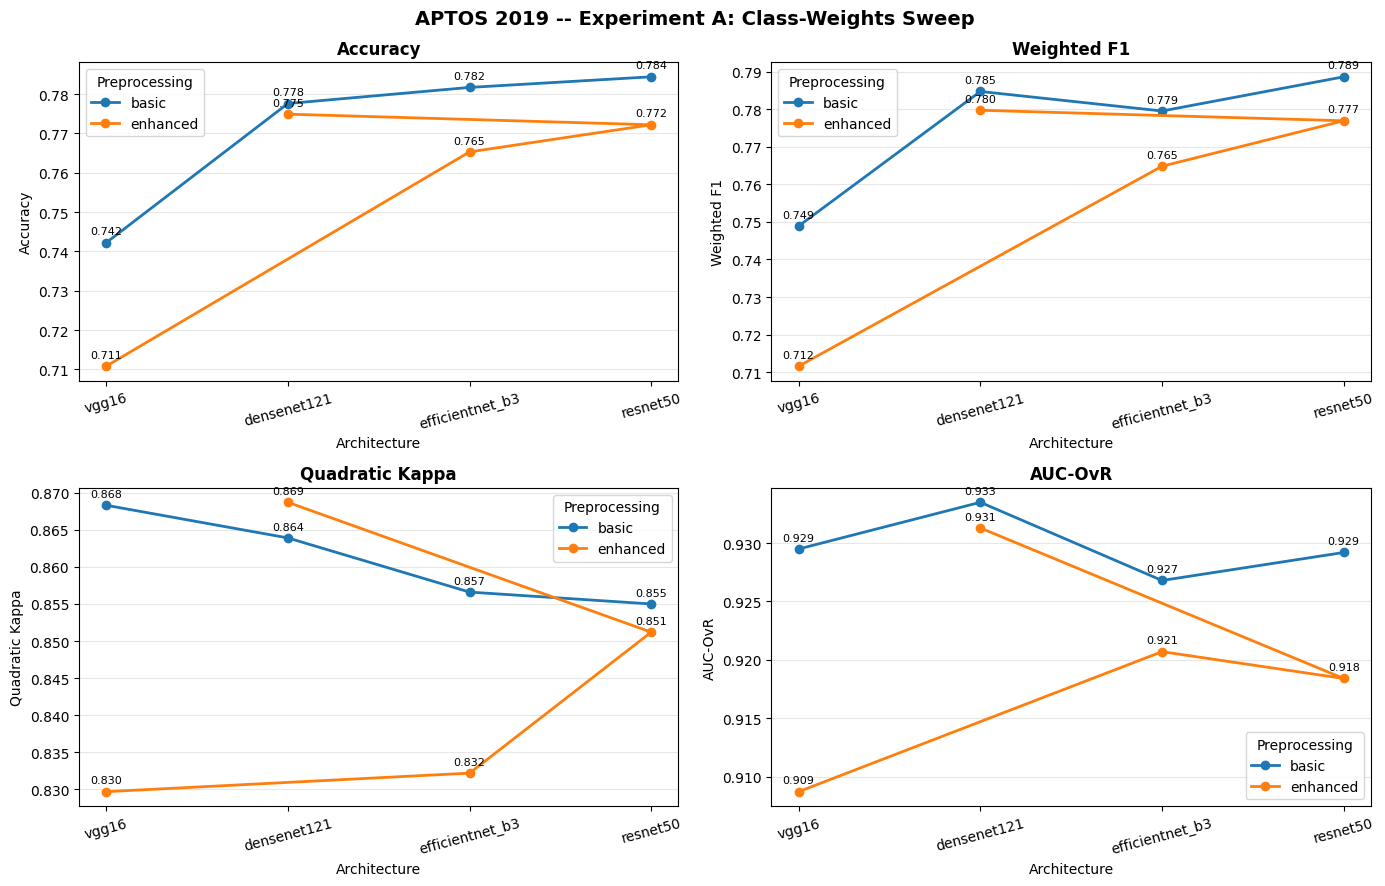

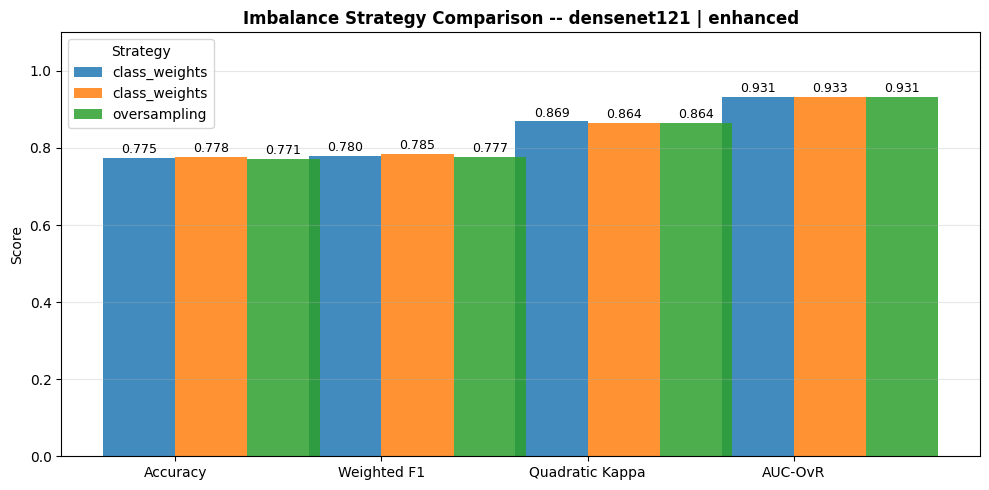

In [42]:
df_A       = df_results[df_results['strategy'] == 'class_weights'].copy()
metric_map = [('acc','Accuracy'), ('f1','Weighted F1'),
              ('kappa','Quadratic Kappa'), ('auc','AUC-OvR')]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (col, label) in zip(axes.flat, metric_map):
    for prep in PREPROCESSING_TYPES:
        sub = df_A[df_A['prep'] == prep]
        ax.plot(sub['arch'], sub[col], marker='o', linewidth=2, label=prep)
        for _, row in sub.iterrows():
            ax.annotate(f"{row[col]:.3f}", (row['arch'], row[col]),
                        textcoords='offset points', xytext=(0, 6),
                        ha='center', fontsize=8)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Architecture')
    ax.set_ylabel(label)
    ax.legend(title='Preprocessing')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('APTOS 2019 -- Experiment A: Class-Weights Sweep',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'benchmark_plots.png'), dpi=150, bbox_inches='tight')
plt.savefig('/kaggle/working/benchmark_plots.png',               dpi=150, bbox_inches='tight')
plt.show()

# Imbalance strategy bar chart (class_weights vs oversampling)
cmp_rows = df_results[df_results['arch'] == best_arch].copy()
strategies   = cmp_rows['strategy'].tolist()
metric_keys  = [m[0] for m in metric_map]
metric_names = [m[1] for m in metric_map]
x     = np.arange(len(metric_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(cmp_rows.iterrows()):
    vals = [row[k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=row['strategy'], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metric_names)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title(f'Imbalance Strategy Comparison -- {best_arch} | {best_prep}',
             fontweight='bold')
ax.legend(title='Strategy')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACTS_DIR, 'strategy_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


In [43]:
best = df_results.iloc[0]


ckpts = {
    row['strategy']: os.path.join(MODELS_DIR, row['ckpt_name'])
    for _, row in df_results[df_results['arch'] == best['arch']].iterrows()
}

config = {
   
    'best_arch'        : best['arch'],
    'best_prep'        : best['prep'],
    'best_strategy'    : best['strategy'],
    'best_kappa'       : best['kappa'],
    'best_acc'         : best['acc'],

   
    'checkpoints'      : ckpts,

   
    'train_split_csv'  : os.path.join(ARTIFACTS_DIR, 'train_split.csv'),
    'val_split_csv'    : os.path.join(ARTIFACTS_DIR, 'val_split.csv'),
    'enhanced_dir'     : ENHANCED_DIR,
    'train_img_dir'    : TRAIN_IMG_DIR,

   
    'num_classes'      : NUM_CLASSES,
    'batch_size'       : BATCH_SIZE,
    'num_workers'      : NUM_WORKERS,
    'class_labels'     : CLASS_LABELS,
    'img_size'         : IMG_SIZE,
    'random_state'     : RANDOM_STATE,

    # Full results
    'results_csv'      : os.path.join(ARTIFACTS_DIR, 'experiment_results.csv'),
}

config_path = os.path.join(ARTIFACTS_DIR, 'best_model_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print('best_model_config.json written\n')
for k, v in config.items():
    if isinstance(v, dict):
        print(f'  {k}:')
        for kk, vv in v.items():
            print(f'    {kk}: {vv}')
    else:
        print(f'  {k:22s}: {v}')

print(f'\nArtifacts in {ARTIFACTS_DIR}:')
for fn in sorted(os.listdir(ARTIFACTS_DIR)):
    fp = os.path.join(ARTIFACTS_DIR, fn)
    print(f'  {fn:50s}  {os.path.getsize(fp)/1024:8.1f} KB')

print(f'\nCheckpoints in {MODELS_DIR}:')
for fn in sorted(os.listdir(MODELS_DIR)):
    fp = os.path.join(MODELS_DIR, fn)
    print(f'  {fn:55s}  {os.path.getsize(fp)/1e6:6.1f} MB')


best_model_config.json written

  best_arch             : densenet121
  best_prep             : enhanced
  best_strategy         : class_weights
  best_kappa            : 0.8687
  best_acc              : 0.7749
  checkpoints:
    class_weights: /kaggle/working/saved_models/densenet121__basic_classweights.pth
    oversampling: /kaggle/working/saved_models/densenet121__enhanced_oversampling.pth
  train_split_csv       : /kaggle/working/artifacts/train_split.csv
  val_split_csv         : /kaggle/working/artifacts/val_split.csv
  enhanced_dir          : /kaggle/working/enhanced_images
  train_img_dir         : /kaggle/input/competitions/aptos2019-blindness-detection/train_images
  num_classes           : 5
  batch_size            : 32
  num_workers           : 4
  class_labels          : ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
  img_size:
    efficientnet_b3: 300
    default: 224
  random_state          : 42
  results_csv           : /kaggle/working/artifacts/experiment_re